# 101.3. Data access overview

<div style="max-width:300px; float: left; margin-right: 1em">

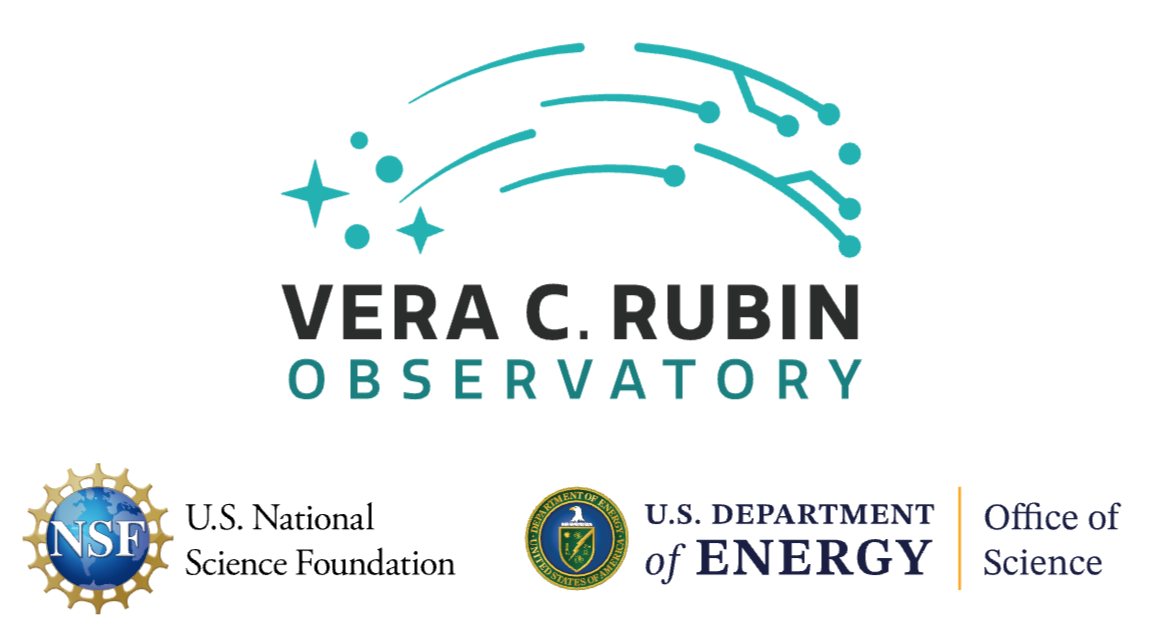

</div>

For the Rubin Science Platform at data.lsst.cloud.\
Data Release: [Data Preview 1](https://dp1.lsst.io/)\
Container Size: Large\
LSST Science Pipelines version: r29.2.0\
Last verified to run: 2026-04-28\
Repository: [github.com/lsst/tutorial-notebooks](https://github.com/lsst/tutorial-notebooks)\
DOI: [10.11578/rubin/dc.20250909.20](https://doi.org/10.11578/rubin/dc.20250909.20)

**Learning objective:** To get a general understanding of the data access services.

**LSST data products:** `Object` table, `deep_coadd` image

**Packages:** `lsst.daf.butler`, `lsst.rsp.get_tap_service`, `lsst.rsp.service.get_siav2_service`

**Credit:**
Originally developed by the Rubin Community Science team.
Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

**Get Support:**
Everyone is encouraged to ask questions or raise issues in the [Support Category](https://community.lsst.org/c/support) of the Rubin Community Forum.
Rubin staff will respond to all questions posted there.

## 1. Introduction

This tutorial provides an overview of simple catalog and image queries in each of the RSP's data access services, TAP (Table Access Protocol), the Butler, and SIA (Simple Image Access). The general use-cases for each service are described, and pointers to more in-depth tutorials for each are provided.

### 1.1. Import packages

Import `numpy` and `matplotlib.pyplot`, modules from the `lsst.afw` package for image display.

Import the following packages to support the data access services.

* Butler: `lsst.daf.butler`
* TAP: `lsst.rsp.get_tap_service`
* SIA: `lsst.rsp.service.get_siav2_service`
* TAP/SIA image retrieval: `lsst.rsp.utils.get_pyvo_auth`, `pyvo.dal.adhoc.DatalinkResults`


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import lsst.afw.display as afwDisplay
from lsst.afw.image import ExposureF
from lsst.daf.butler import Butler
from lsst.rsp import get_tap_service
from lsst.rsp.service import get_siav2_service
from lsst.rsp.utils import get_pyvo_auth
from pyvo.dal.adhoc import DatalinkResults

### 1.2. Define parameters

Instantiate the TAP service.

In [ ]:
tap_service = get_tap_service("tap")
assert tap_service is not None

Instantiate the Butler.

In [ ]:
butler = Butler("dp1", collections="LSSTComCam/DP1")
assert butler is not None

Instantiate the SIA service.

In [ ]:
sia_service = get_siav2_service("dp1")
assert sia_service is not None

Open the image display tab, Firefly, and ready frame 1 for display.

In [ ]:
afwDisplay.setDefaultBackend("firefly")
afw_display = afwDisplay.Display(frame=1)

Define a target coordinates in RA, Dec, and a radius (all in degrees) to use in example queries.
These coordinates are for the center of the Extended Chandra Deep Field South (ECDFS) field for DP1.

In [ ]:
targ_ra = 53.2
targ_dec = -28.1
rad = 0.5

## 2. Catalog data

Catalog data is accessible via the TAP and Butler services.

**Related tutorials:**
* The 200-level series "Catalogs" contains more details about the format and contents of TAP-accessible tables.

### 2.1. TAP

TAP ([Table Access Protocol](http://www.ivoa.net/documents/TAP)) is the recommended service for catalog data access.
The TAP service takes queries in ADQL ([Astronomy Data Query Language](http://www.ivoa.net/documents/latest/ADQL.html)).

TAP catalog queries should:
* have spatial constraints
* specify the columns to return
* be run asynchronously

**Related tutorials:**
* The 100-level series "Catalog access" contains guidance on efficient queries and advanced TAP query options such as schema browsing, polygon spatial queries, table joins, derived values, sorting, grouping, cross-match, and so on.
* The 300-level series "Interactive data visualization" demonstrates how to make more sophisticated, interactive plots that can accommodate millions of data points.

**Execute a TAP query.** Create an ADQL query that will select (return values in) the following columns of the `Object` table: the Object identifier, right ascension and declination, $g$- and $r$-band `cModelMag`.
Include spatial constraints as a cone search that will only return objects within the specified radius of the target RA and Dec (in degrees), and include column constraints that magnitudes must be between 17 and 23 mag.
Run the query as an asynchronous job, then fetch the results as an Astropy table with `.to_table()`.
This query returns a very modest number of rows.

In [ ]:
query = """SELECT objectId, coord_ra, coord_dec, g_cModelMag AS gmag, r_cModelMag AS rmag
        FROM dp1.Object
        WHERE CONTAINS(POINT('ICRS', coord_ra, coord_dec), CIRCLE('ICRS', {}, {}, {})) = 1
        AND g_cModelMag < 23 AND r_cModelMag < 23 AND g_cModelMag > 17 AND r_cModelMag > 17
        """.format(targ_ra, targ_dec, rad)
job = tap_service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
tbl = job.fetch_result().to_table()
print('Number of rows returned: ', len(tbl))

Option to view the results table.

In [ ]:
# tbl

**Visualize the results data** with a color-magnitude diagram.

In [ ]:
fig = plt.figure(figsize=(4, 3))
plt.plot(tbl['gmag']-tbl['rmag'], tbl['rmag'], 'o', ms=3, mew=0, alpha=0.2, color='black')
plt.xlabel('g-r')
plt.ylabel('r')
plt.show()

> **Figure 1:** A color-magnitude diagram for the TAP results.

Delete the job, query, and results.

In [ ]:
job.delete()
del query, tbl

### 2.2. Butler

The Butler is the LSST Science Pipelines interface for managing, reading, and writing datasets. As the interface between the pipelines and the data, it is often referred to as "middleware".

The TAP service is recommended for catalog access because with the Butler, tables are returned for an entire visit or tract and queries with coordinate or column constraints are not possible. Butler catalog access is most useful when all of the sources in a given visit or tract are desired.

Butler catalog queries should:
* desire all sources/objects in a given visit/tract
* specify the columns to return

**Related tutorials:**
* The 100-level series "Butler data access" contains more information on dataset types, use of the `dataId`, spatial and temporal queries, bind parameters, sorting, and applying limits.

**Create a butler query** to find all object table tracts that overlap the target coordinates.
In this example there is only one overlapping tract, but note that tracts do overlap at their edges and corners, so it could be up to four.
Define the columns to return, and get the results from the Butler.

In [ ]:
query = """tract.region OVERLAPS POINT({}, {})""".format(targ_ra, targ_dec)
refs = butler.query_datasets("object", where=query)
print('Number of overlapping object tract tables: ', len(refs))
column_names = ['objectId', 'coord_ra', 'coord_dec', 'g_cModelFlux', 'r_cModelFlux']
tbl = butler.get(refs[0], parameters={'columns': column_names})
print('Number of objects retrieved for tract: ', len(tbl))

The Butler stores the data in fluxes only (the units are nJy). Convert positive fluxes to AB magnitudes. (All fluxes in the Object table are forced photometry, and can be negative for objects with no discernible flux due to random fluctuations in the sky-subtracted background of the image.)

In [ ]:
tbl['gmag'] = np.zeros(len(tbl), dtype='float') + 99
tbl['rmag'] = np.zeros(len(tbl), dtype='float') + 99
gx = np.where(tbl['g_cModelFlux'] > 0.0)[0]
tbl['gmag'][gx] = -2.5 * np.log10(tbl['g_cModelFlux'][gx]) + 31.4
rx = np.where(tbl['r_cModelFlux'] > 0.0)[0]
tbl['rmag'][rx] = -2.5 * np.log10(tbl['r_cModelFlux'][rx]) + 31.4
del gx, rx

**Visualize the results data.** Create the same plots as in Figure 1 for a random sub-set of 10000 objects, and only where the forced photometry magnitude is $<30$ mag.

In [ ]:
fig = plt.figure(figsize=(4, 3))
tx = np.where((tbl['gmag'] < 30) & (tbl['rmag'] < 30))[0]
rx = np.random.choice(tx, size=10000, replace=False)
plt.plot(tbl['gmag'][rx]-tbl['rmag'][rx], tbl['rmag'][rx],
         'o', ms=3, mew=0, alpha=0.2, color='black')
plt.xlabel('g-r')
plt.ylabel('r')
plt.show()
del tx, rx

> **Figure 2:** A color-magnitude diagram for the Butler results.

Delete the query and the results.

In [ ]:
del query, refs, column_names, tbl

## 3. Image data

Image data is accessible via the Butler, SIA, and TAP services.

**Related tutorials:**
* The 100-level series "Image access and display" contains detailed demonstrations for each of the RSP's image query and visualization services.
* The 200-level series "Images" contains more information about image formats and metadata, such as the mask plane, WCS, PSF, and so on.

### 3.1. Butler

The Butler is the recommended tool for image access.

Butler catalog queries should:
* include a spatial constraint (e.g., overlaps point)

**Related tutorials:**
* The 100-level series "Butler data access" contains more information on dataset types, use of the `dataId`, spatial and temporal queries, bind parameters, sorting, and applying limits.

**Create a Butler query** for $r$-band deep coadd patch images that overlap the target coordinates, retrieve the first in the `refs` list from the Butler.

In [ ]:
query = f"band.name = 'r' AND patch.region OVERLAPS POINT({targ_ra}, {targ_dec})"
refs = butler.query_datasets("deep_coadd", where=query)
print('Number of overlapping deep coadd patches: ', len(refs))
deep_coadd = butler.get(refs[0])

**Display the deep coadd image in Firefly** and set the mask to be fully transparent so that only the pixel data is shown.

In [ ]:
afw_display.mtv(deep_coadd)
afw_display.setMaskTransparency(100)

The image in the Firefly viewer should look like the following.

<div style="max-width:300px">

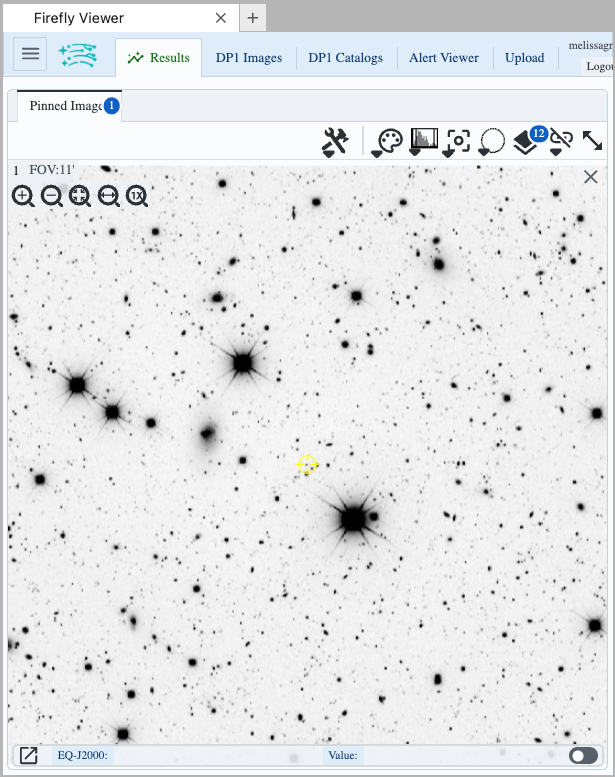

</div>

> **Figure 3:** The $r$-band deep coadd image displayed in the Firefly window.

Delete the query and the results.

In [ ]:
del query, refs, deep_coadd

### 3.2. SIA

SIA (Simple Image Access) is a protocol of the International Virtual Observatory Alliance (IVOA) that provides a standardized model for image metadata (spatial, temporal, and spectral coverage).

SIA queries should specify:
* spatial constraints (coordinate or region overlap)
* a calibration level and an image subtype

Calibration levels and data product subtypes names are:
 - 1 : `raw`
 - 2 : `visit_image`
 - 3 : `deep_coadd`, `template_coadd`, `difference_image`

Additional constraints on band, time, and date are also possible.

**Related tutorials:**
* The 100-level series "Image access and display" contains a SIA tutorial, including how to put constraints on the filter.

**Create a SIA query** for deep coadd images that overlap a 0.05 deg circle centered on the target RA, Dec defined above.

In [ ]:
circle = (targ_ra, targ_dec, 0.05)
tbl = sia_service.search(pos=circle, calib_level=3, dpsubtype='lsst.deep_coadd').to_table()

Option to display table of image metadata.

In [ ]:
# tbl

Select the $r$-band image from the table, and display the row.
Get the `image_url` for the $r$-band image.

In [ ]:
tx = np.where(tbl['lsst_band'] == 'r')[0]
tbl[:][tx]
datalink_url = tbl['access_url'][tx[0]]
dl_result = DatalinkResults.from_result_url(datalink_url, session=get_pyvo_auth())
image_url = dl_result.getrecord(0).get('access_url')
del tx

Use the `image_url` to retrieve the deep coadd image.

In [ ]:
deep_coadd_2 = ExposureF(image_url)

**Display the image** in a second frame in the Firefly window. It will be the same as the image displayed in Section 3.1 above.

In [ ]:
afw_display = afwDisplay.Display(frame=2)
afw_display.mtv(deep_coadd_2)
afw_display.setMaskTransparency(100)

Delete the query and the results.

In [ ]:
del circle, tbl, datalink_url, dl_result, image_url, deep_coadd_2

### 3.3. TAP

The ObsCore table contains image metadata and is accessible via the TAP service. It's the same image metadata table accessed by SIA, and the TAP service as demonstrated for catalogs in Section 2.1.

ObsCore TAP queries should specify:
* spatial constraints (coordinate or region overlap)
* an image subtype

The image subtypes are `raw`, `visit_image`, `deep_coadd`, `template_coadd`, `difference_image`. Additional constraints on band, time, and date are also possible.

**Related tutorials:**
* The 100-level series "Image access and display" contains an ObsCore TAP tutorial, demonstrating options for spatial and temporal query constraints.

**Create an ObsCore TAP query** for the $r$-band deep coadd image that contains the target RA, Dec. Execute the query and return the table of results, which will have just 1 row.

In [ ]:
query = """SELECT * FROM ivoa.ObsCore
        WHERE CONTAINS(POINT('ICRS', {}, {}), s_region) = 1
        AND dataproduct_subtype = 'lsst.deep_coadd' AND lsst_band = 'r'
        """.format(targ_ra, targ_dec)
job = tap_service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
if job.phase == 'ERROR':
    job.raise_if_error()
assert job.phase == 'COMPLETED'
tbl = job.fetch_result().to_table()
print('Number of rows returned: ', len(tbl))

Option to display the one-row table.

In [ ]:
# tbl

From here, the sequence to obtain and display the image is the same as when the `access_url` for the image is retrieved from the SIA service.

Get the deep coadd image for a third time, and display it in Firefly frame 3.

In [ ]:
datalink_url = tbl['access_url'][0]
dl_result = DatalinkResults.from_result_url(datalink_url, session=get_pyvo_auth())
image_url = dl_result.getrecord(0).get('access_url')

deep_coadd_3 = ExposureF(image_url)

afw_display = afwDisplay.Display(frame=3)
afw_display.mtv(deep_coadd_3)
afw_display.setMaskTransparency(100)

Delete the job, query, and results.

In [ ]:
job.delete()
del query, tbl, datalink_url, dl_result, image_url, deep_coadd_3